<h1 style="text-align: center;">Exploratory Data Analysis</h1>
<h3 style="text-align: center;">Bank Marketing Campaign</h3>

---

<h5 style="text-align: right;">By Elmar leonard & Nadya Divia Go</h5>

# **Section 0: Setup**

## **0.1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway

## **0.2. Global Configuration**

In [2]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df =  pd.read_csv(r"..\\data\\interim\\cleaned_data_bank_marketing_campaign.csv")

# **Section 1: EDA**

## **1.1 Univariate Analysis**

### **1.1.1 Target Distribution**

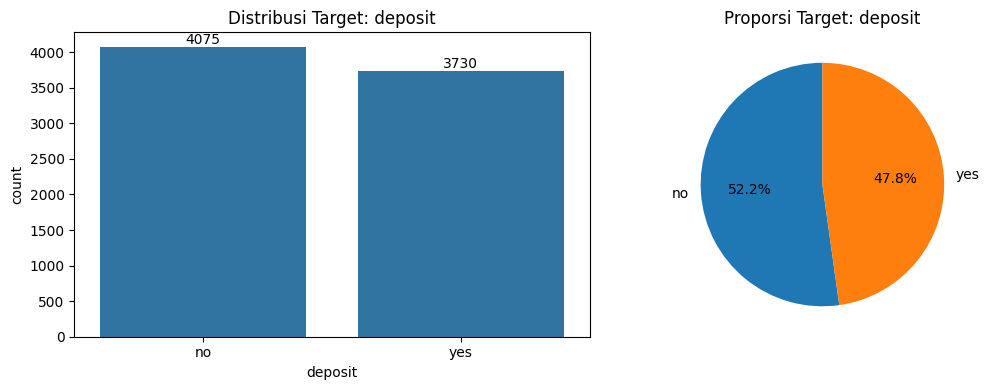

deposit
no     4075
yes    3730
Name: count, dtype: int64
deposit
no     52.21
yes    47.79
Name: proportion, dtype: float64


In [3]:
target_counts = df['deposit'].value_counts()
target_pct = df['deposit'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='deposit', order=['no', 'yes'], ax=ax[0])
ax[0].set_title("Distribusi Target: deposit")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom')

ax[1].pie(target_pct, labels=target_pct.index, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette()[:2])
ax[1].set_title("Proporsi Target: deposit")
plt.tight_layout()
plt.show()

print(target_counts)
print(target_pct.round(2))

To understand the baseline distribution of our target variable, we plotted the frequency and proportion of customer campaign outcomes (`yes` vs. `no` subscriptions to the term deposit):

* **Highly Balanced Target Distribution:** Out of 7,805 unique customer records, **52.2% (4,075 records)** declined the offer (`no`), while **47.8% (3,730 records)** successfully subscribed to a term deposit (`yes`).
* **Ideal Machine Learning Conditions:** Traditional banking marketing datasets typically exhibit extreme class imbalances (e.g., 90% 'no' vs. 10% 'yes'). Our dataset's near 52/48 split is exceptionally balanced, meaning the machine learning algorithms can learn features of both classes with equal clarity.
* **Modeling & Evaluation Impact:** Because there is no dominant majority class, we can entirely skip complex class-balancing techniques like SMOTE, downsampling, or adjusting `class_weight` parameters. Furthermore, standard evaluation metrics like **Accuracy** and **ROC-AUC** will remain highly robust, objective, and free from majority-class bias.


### **1.1.2 Numerical Feature Distribution**

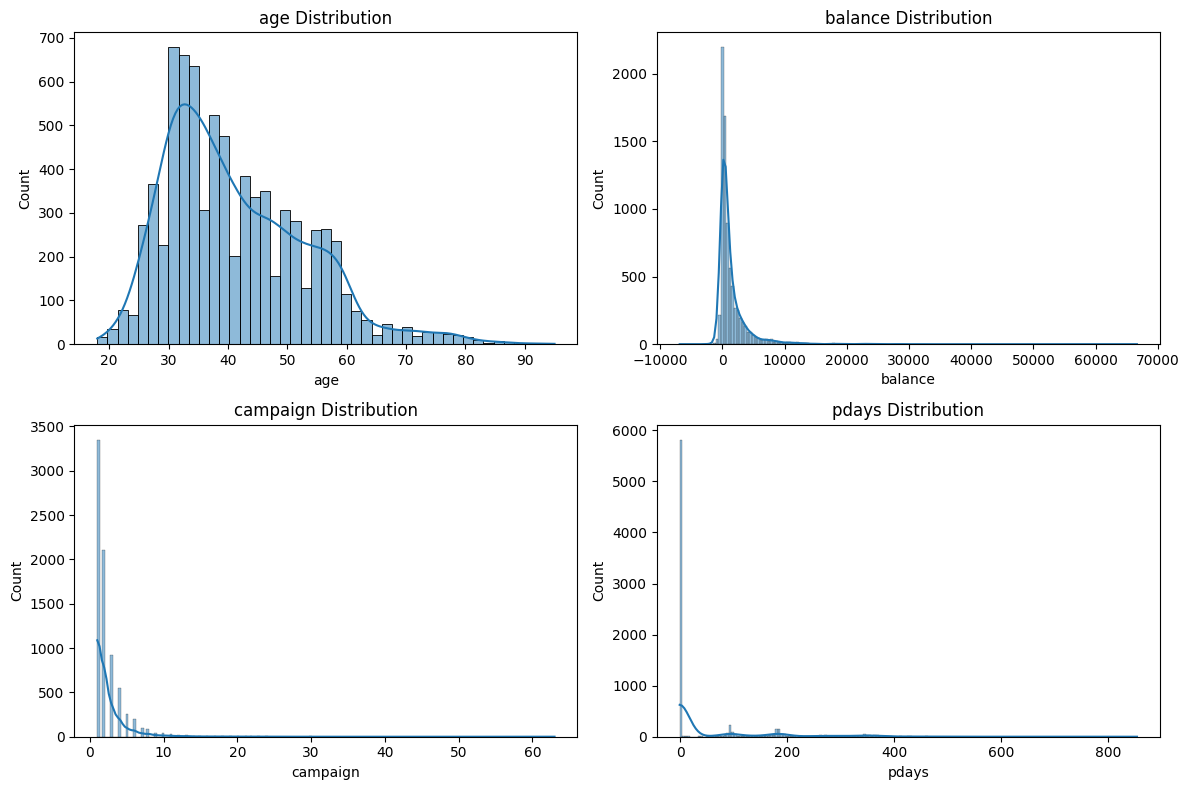

,skewness
age,0.867338
balance,6.758241
campaign,5.535701
pdays,2.409577


In [4]:
num_features = ['age', 'balance', 'campaign', 'pdays']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()

df[num_features].skew().rename("skewness").to_frame()

To assess the structural distributions and mathematical distributions of our continuous variables, we plotted histograms with Kernel Density Estimate (KDE) lines and analyzed their skewness values:

* **`age` Distribution (Skewness: 0.87):**
  * **Observation:** This distribution exhibits a slight right-skew. The majority of targeted clients are clustered between the ages of 30 and 45, peaking sharply around age 32. 
  * **Modeling Impact:** At 0.87, the skewness is mild. It represents a relatively standard demographic distribution that will require minimal transformation before being fed into our models.
* **`balance` Distribution (Skewness: 6.76):**
  * **Observation:** This feature features extreme right-skewness. A massive spike of users hovers around a balance of 0 to 1,500, while a long, thin tail extends out past 60,000.
  * **Modeling Impact:** A skewness score of 6.76 is highly volatile. Distance-based or linear models (like Logistic Regression or SVM) will struggle with this data variance. This confirms our strategy to use **Winsorization** to cap the extreme tails and a **RobustScaler** to handle the scale variation.
* **`campaign` Distribution (Skewness: 5.54):**
  * **Observation:** The contact frequency is heavily skewed to the left. The overwhelming majority of customers were contacted only 1 to 3 times during this current campaign cycle. However, extreme operational outliers exist where some clients were called over 60 times.
  * **Modeling Impact:** The high skewness proves that most interactions happen early, and the long tail represents operational noise that will be cleanly smoothed out via our planned upper-bound Winsorization filter.
* **`pdays` Distribution (Skewness: 2.41):**
  * **Observation:** The distribution features a massive isolated spike right at the start. This represents the high volume of `-1` entries, confirming visually that most entries are entirely new prospects who have never been part of an historical campaign cycle.
  * **Modeling Impact:** Because `-1` acts as a structural category flag rather than a true continuous number, this feature will be carefully handled (or paired with a binary indicator feature like `is_previously_contacted`) during our preprocessing phase to ensure the model interprets the `-1` cliff correctly.


### **1.1.3 Categorical Feature Distribution**

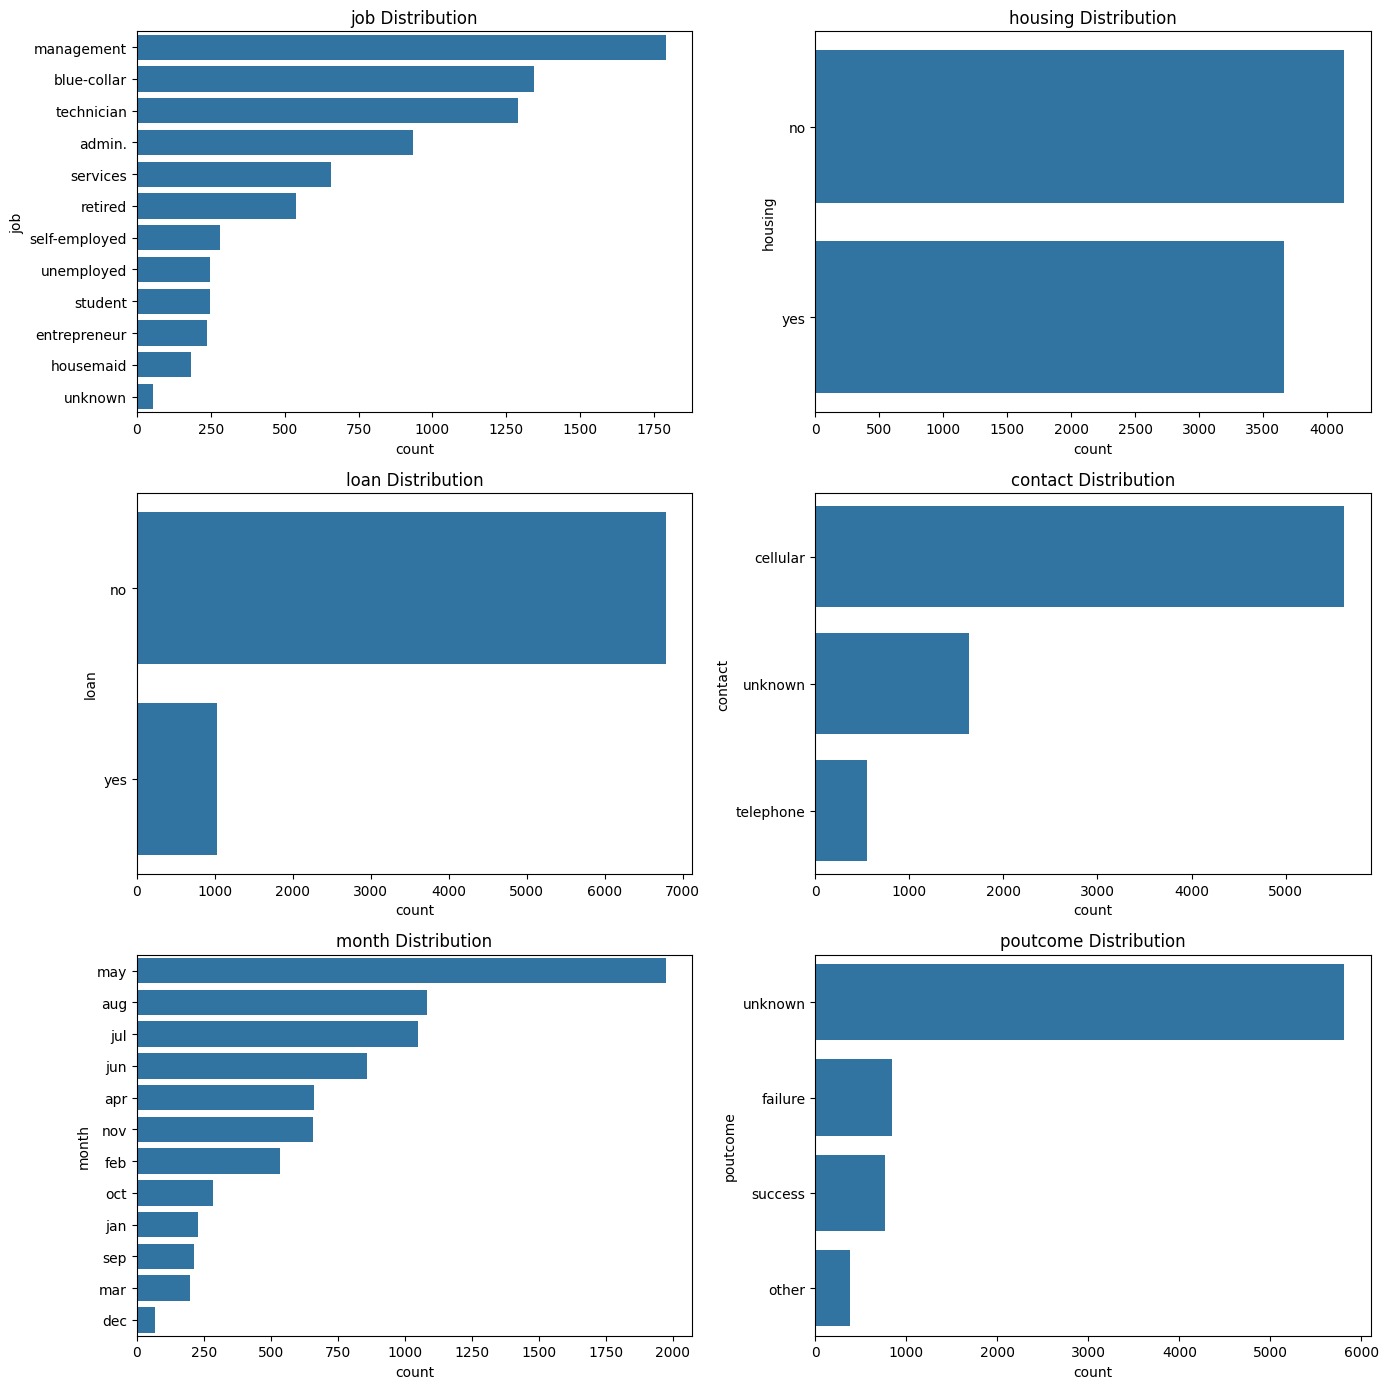

In [5]:
cat_features = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()

To understand the core demographic and operational patterns of the bank's customer base, we analyzed the distributions across our 6 categorical features:

* **Customer Professional Profile (`job`):** The data is dominated by three main employment segments: `management`, `blue-collar`, and `technician`. Together, they represent over half of the total customer database. Conversely, specialized segments like `entrepreneur`, `housemaid`, and `unknown` represent minor fragments of the pool.
* **Liability & Debt Exposure (`housing` & `loan`):** 
  * The dataset shows a balanced split regarding home ownership debts, with slightly more customers having no active housing loans (`no`) compared to those with active mortgages (`yes`).
  * Personal loans show a heavy imbalance, with the vast majority of prospects being entirely free from short-term personal debt overhead (`no`). This indicates a highly liquid target audience with uncommitted capital available for investment products.
* **Campaign Channel Dynamics (`contact`):** Modern mobile communication is heavily prioritized by the marketing team. `cellular` contact is by far the most dominant touchpoint, completely eclipsing traditional landline `telephone` outreach. A notable portion of the communication channels remains logged as `unknown`.
* **Outreach Seasonality (`month`):** The campaign exhibits an aggressive seasonal bottleneck. Marketing outreach peaks massively in `may`, followed by secondary waves during the summer months (`aug`, `jul`, `jun`). In stark contrast, winter months like `dec`, `mar`, and `sep` show practically zero campaign activity.
* **Historical Campaign Memory (`poutcome`):** Nearly three-quarters of the entire dataset falls into the `unknown` outcome category. This confirms that the overwhelming majority of prospects are net-new leads with no historical tracking or interaction data from prior bank campaigns.


## **1.2 Bivariate Analysis (on Target)**

### **1.2.1 Numerical Feature to Target**

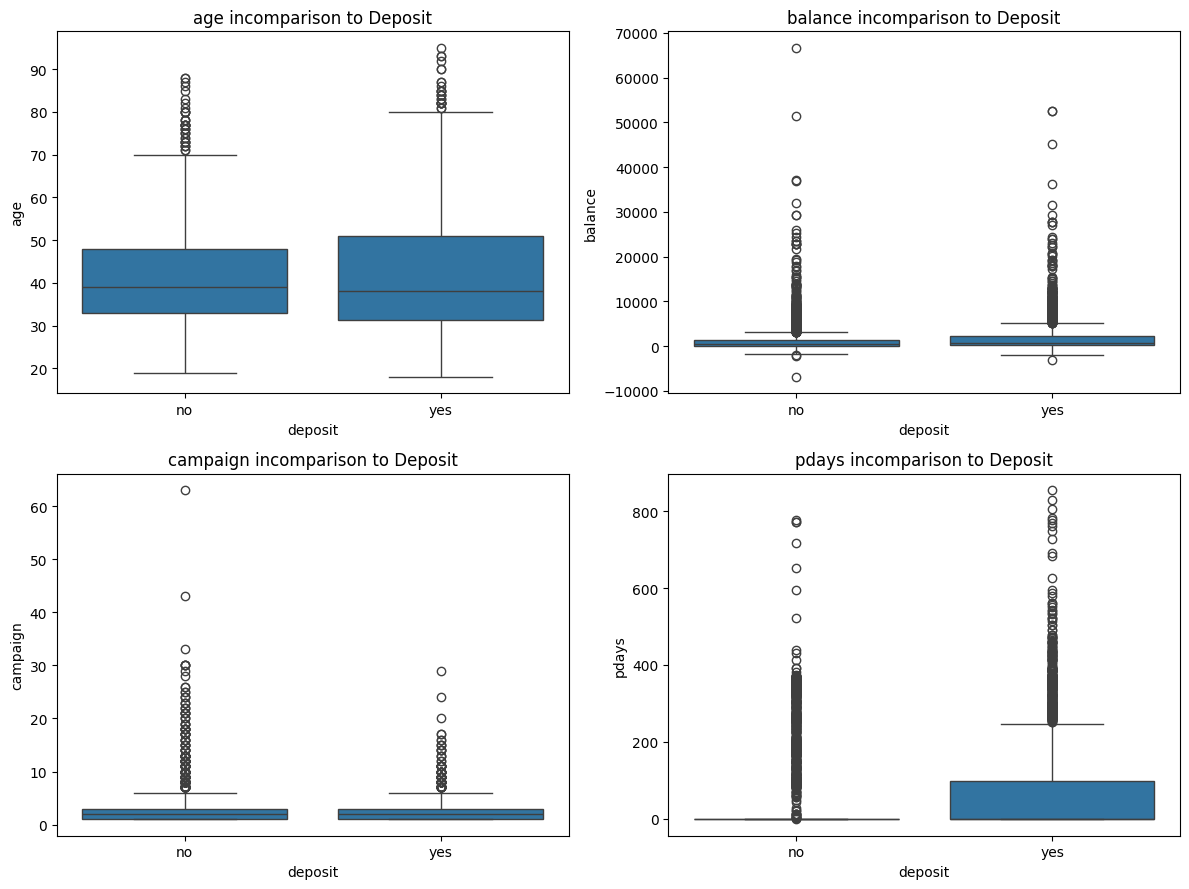

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    sns.boxplot(data=df, x='deposit', y=col, order=['no', 'yes'], ax=ax)
    ax.set_title(f"{col} incomparison to Deposit")
plt.tight_layout()
plt.show()

To understand how our continuous numerical variables influence a customer's decision to open a term deposit, we analyzed boxplots grouped by the target classes (`yes` vs. `no`):

* **`age` vs. `deposit`:**
  * **Observation:** The median age between those who subscribe and those who do not is practically identical (around 38–39 years old). However, looking closely at the upper outliers, there is a significantly higher density of older clients (ages 60 to 95) who successfully open a term deposit (`yes`).
  * **Strategic Insight:** While the working-class majority acts similarly, senior citizens show a distinct positive propensity toward deposit products. This reinforces our earlier decision **not to modify senior age outliers**, as they provide an important conversion signal.
* **`balance` vs. `deposit`:**
  * **Observation:** The interquartile range (IQR) boxes for both groups look heavily compressed due to extreme outlier scales. However, the median and overall distribution of the `yes` group are slightly higher and wider than the `no` group.
  * **Strategic Insight:** Customers with higher account balances possess greater financial liquidity, making them more receptive to locking away funds in a term deposit. This highlights the vital need for our planned **Winsorization pipeline** to smooth out the multi-thousand spikes while preserving this upward trend.
* **`campaign` vs. `deposit`:**
  * **Observation:** For both groups, the median number of contacts sits low at 2. However, the `no` group features a much higher density of extreme upper outliers—reaching up to 40 and 60 contacts—whereas the `yes` group spikes drop off significantly past 10–15 calls.
  * **Strategic Insight:** **Customer contact fatigue is a real operational issue.** Bombarding a customer with an excessive number of phone calls does not drive new conversions; instead, it wastes sales resources and annoys prospects who have already decided to decline.
* **`pdays` vs. `deposit`:**
  * **Observation:** The `no` group box plot is completely flat at 0 because the overwhelming majority are brand-new leads coded as `-1`. In contrast, the `yes` box plot shows a much wider distribution, indicating that a significant portion of successful conversions comes from clients who *were* previously contacted within the last 100 to 200 days.
  * **Strategic Insight:** Nurturing existing customer relationships and re-engaging old leads yields a much higher probability of campaign success compared to blindly pitching cold, net-new prospects.


### **1.2.2 Categorical Feature to Target**

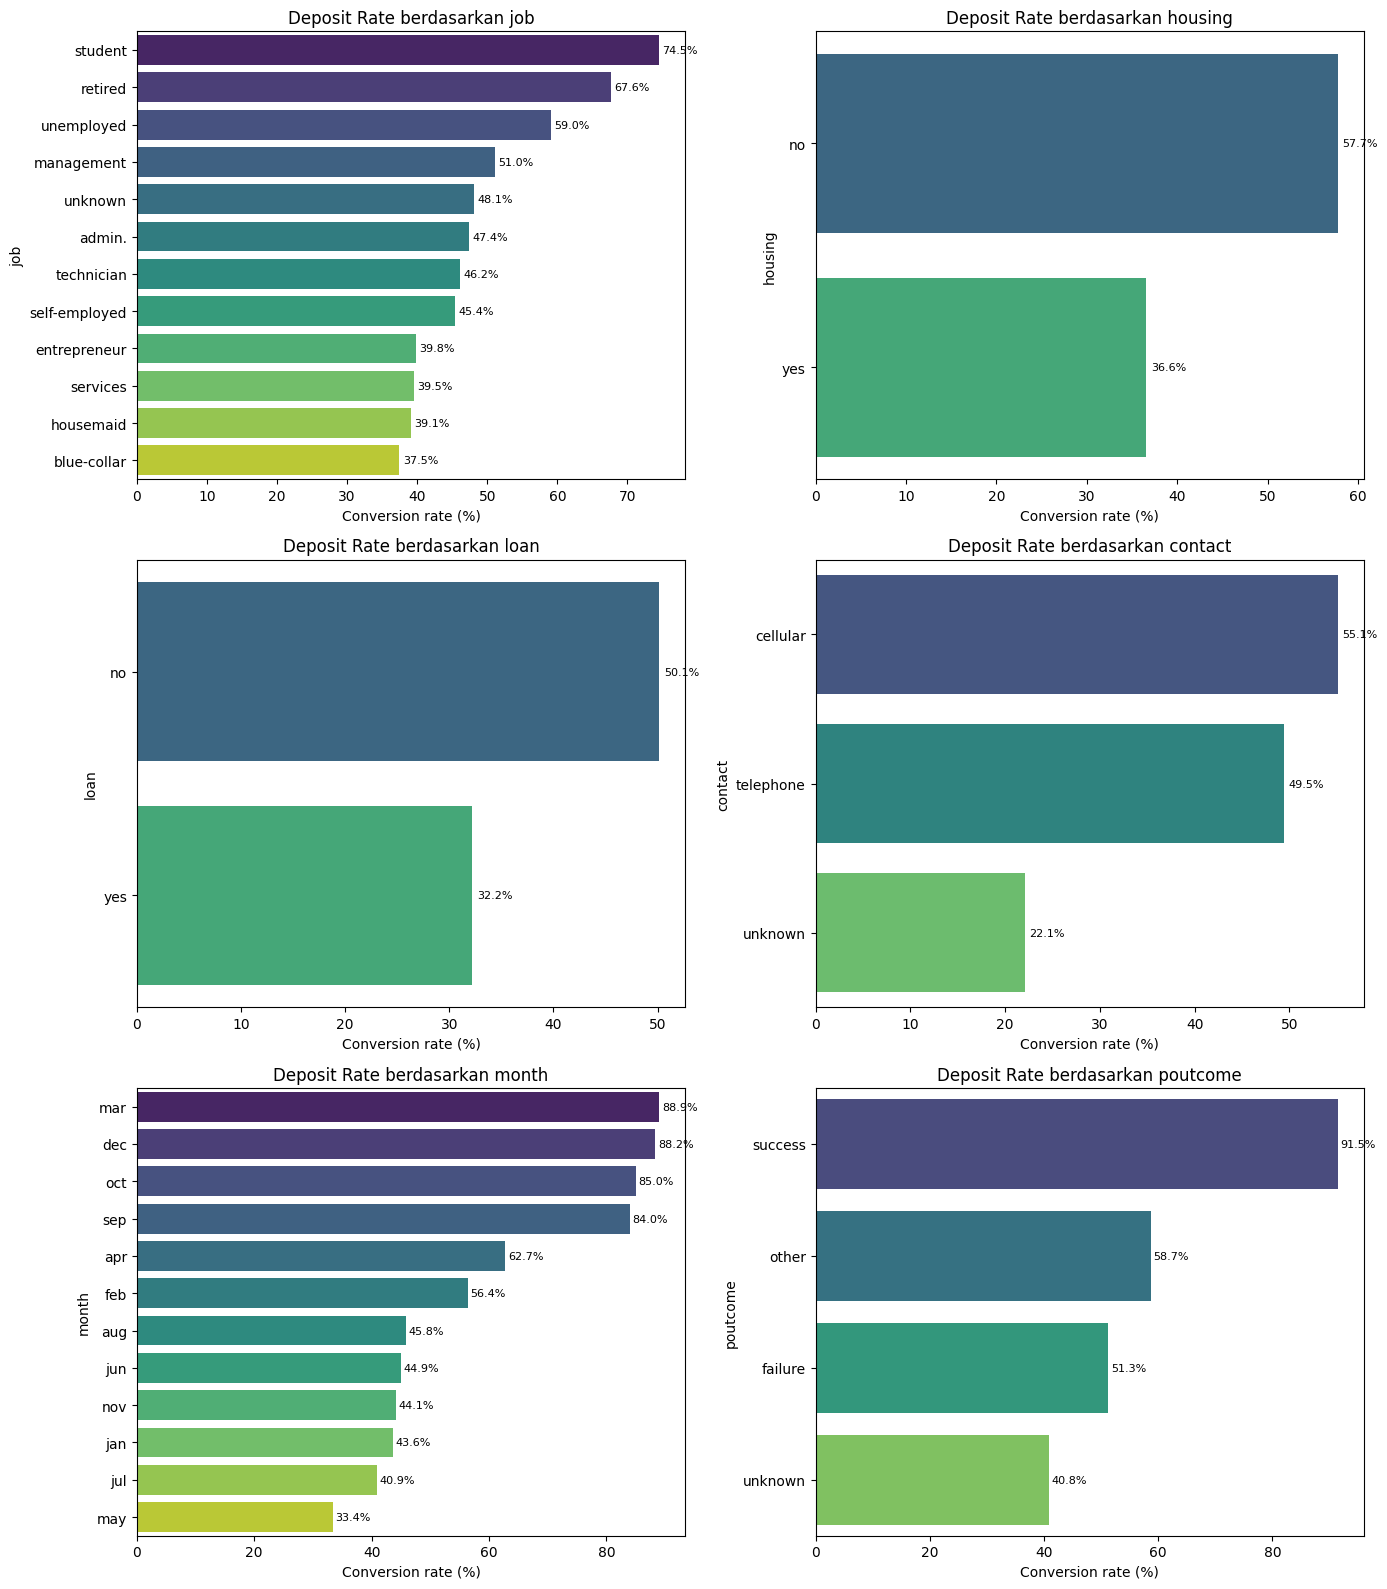

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    conv_rate = (df.groupby(col)['deposit']
                   .apply(lambda x: (x == 'yes').mean() * 100)
                   .sort_values(ascending=False))
    sns.barplot(x=conv_rate.values, y=conv_rate.index, ax=ax, palette="viridis", hue=conv_rate.index, legend=False)
    ax.set_xlabel("Conversion rate (%)")
    ax.set_title(f"Deposit Rate berdasarkan {col}")
    for i, v in enumerate(conv_rate.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

To isolate the specific drivers of campaign success, we analyzed the direct conversion rates (percentage of `yes` outcomes) across all categorical dimensions. The findings provide highly actionable target segments for the bank's future outreach strategy:

* **Deposit Rate by Job (`job`):**
  * **Observation:** **`student` (74.5%)** and **`retired` (67.6%)** profiles yield the absolute highest conversion rates in the dataset. Conversely, `blue-collar` workers sit at the bottom with a low 37.5% conversion rate.
  * **Strategic Insight:** While students and retirees represent smaller total volumes in our database, their willingness to subscribe is exceptionally high. Retirees look for stable interest income, and students appreciate structured savings. The sales team should actively prioritize these two high-yield segments.
* **Deposit Rate by Debt Liabilities (`housing` & `loan`):**
  * **Observation:** Customers with **no housing loans convert at 57.1%** (vs. 36.6% for mortgage holders), and customers with **no personal loans convert at 50.1%** (vs. 32.2% for debt holders).
  * **Strategic Insight:** There is a clear negative correlation between personal debt obligations and investment behavior. Clients who are entirely free from the financial stress of active mortgages and personal loans possess the uncommitted cash liquidity required to open fixed-term deposits. Debt-free profiles should be heavily prioritized.
* **Deposit Rate by Communication Channel (`contact`):**
  * **Observation:** **`cellular` outreach leads with a 55.1% success rate**, followed closely by traditional landline `telephone` at 49.5%. However, campaigns where the contact method was logged as `unknown` crashed down to an ineffective 22.1%.
  * **Strategic Insight:** Direct mobile-based communication is the most effective approach. The 22.1% conversion rate for `unknown` entries proves that poor administrative tracking or indirect outreach heavily harms sales success.
* **Deposit Rate by Operational Seasonality (`month`):**
  * **Observation:** Off-peak shoulder months yield spectacular conversion rates: **`mar` (88.9%)**, **`dec` (88.2%)**, **`oct` (85.0%)**, and **`sep` (84.0%)**. In contrast, the bank’s heaviest operational peak month `may` results in the absolute lowest conversion rate in the entire dataset at just 33.4%.
  * **Strategic Insight:** **The bank is suffering from extreme operational inefficiency.** The marketing team is flooding customers with calls in May when conversion interest is dead, while completely under-utilizing high-intent periods like March and December. Spreading out campaign resources into these high-converting off-peak months will massively boost total revenue.
* **Deposit Rate by Previous Campaign History (`poutcome`):**
  * **Observation:** Prospects with a historical **`success` tag convert at an astronomical 91.5% rate**. Even clients labeled as a previous `failure` still convert at 51.3%, which is notably higher than net-new prospects logged as `unknown` (40.8%).
  * **Strategic Insight:** **Past positive behavior is the single strongest predictor of future success.** A client who has already trusted the bank with a past product is almost guaranteed to buy again. Furthermore, a past "No" (`failure`) is not a dead end; these clients have established familiarity with the bank and still convert better than completely cold, uncontacted leads.


## **1.3 Correlation & Multicollinearity Check**

### **1.3.1 Numerical Association (Correlation Matrix)**

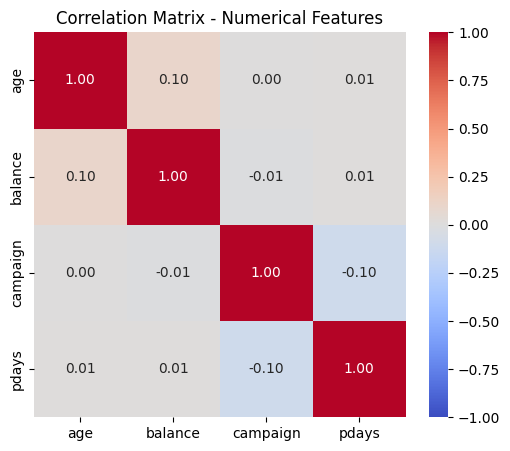

In [8]:
plt.figure(figsize=(6, 5))
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Numerical Features")
plt.show()

To check for multi-variable patterns and detect potential multicollinearity risks that could destabilize our machine learning algorithms, we generated a Pearson Correlation Matrix across all continuous numerical variables:

* **Zero Multicollinearity Risk:** All off-diagonal correlation scores hover exceptionally close to zero, ranging strictly between **-0.10 and 0.10**. This proves that there is zero linear dependency or redundant information overlapping among our continuous predictors.
* **Algorithm Compatibility:** Because there is no multicollinearity present, our baseline linear models (like Logistic Regression) will remain highly stable and free from coefficient inflation. We do not need to drop any numerical columns via Variance Inflation Factor (VIF) checks.
* **Independence of Features:** 
  * The correlation between `age` and `balance` is very weak (0.10), meaning older customers are not automatically assumed to have higher account balances in this specific pool.
  * The mild negative correlation between `campaign` and `pdays` (-0.10) shows that as the number of calls in this campaign increases, the time elapsed since the last campaign shows a slight downwards shift. This represents a minor behavioral clustering from the outreach process but remains far below any level of statistical concern.


### **1.3.2 Association Strength of Categorical Features vs. Target (Cramér's V)**

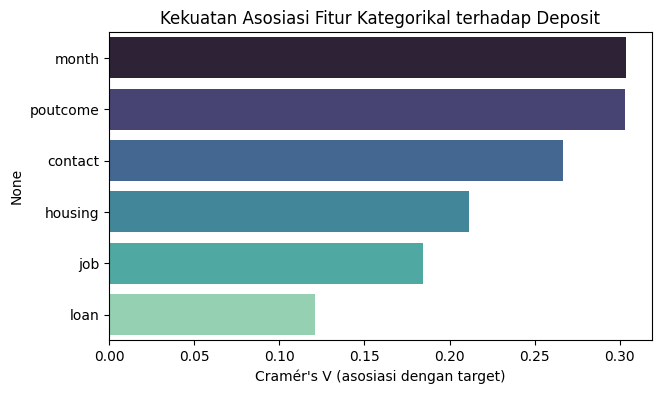

month       0.303384
poutcome    0.303043
contact     0.266741
housing     0.211173
job         0.184196
loan        0.120697
dtype: float64

In [9]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

assoc = {col: cramers_v(df[col], df['deposit']) for col in cat_features}
assoc_series = pd.Series(assoc).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=assoc_series.values, y=assoc_series.index, palette="mako", hue=assoc_series.index, legend=False)
plt.xlabel("Cramér's V (asosiasi dengan target)")
plt.title("Kekuatan Asosiasi Fitur Kategorikal terhadap Deposit")
plt.show()

assoc_series

To quantify the relationship between our categorical features and the target variable (`deposit`), we calculated the **Cramér's V** coefficient based on a Chi-Square Test of Independence. This ranking serves as an excellent indicator of feature importance prior to model training:

* **Top Tier: Strong Operational & Historical Drivers (`month` & `poutcome`)**
  * **`month` (0.303) & `poutcome` (0.303):** These features show the strongest association with customer conversion. 
  * **Business Meaning:** A value above 0.30 is highly significant. This proves that *when* you contact a customer (seasonality) and *how* they responded in the past (campaign memory) are the most powerful categorical indicators of whether they will open a term deposit. 

* **Mid Tier: Core Campaign Logistics & Financial Liabilities (`contact` & `housing`)**
  * **`contact` (0.266) & `housing` (0.211):** These features exhibit a moderate-to-strong relationship with the target.
  * **Business Meaning:** The chosen communication channel (e.g., cellular vs. unknown tracking) and the customer's massive asset debt burden (having a mortgage) strongly sway their investment flexibility and willingness to respond.

* **Lower Tier: Demographics & Short-Term Debt (`job` & `loan`)**
  * **`job` (0.184) & `loan` (0.120):** While ranking lower on the scale, these features still sit safely above the 0.10 threshold, indicating they carry valid predictive signals.
  * **Business Meaning:** A client's specific professional bracket and their personal loan overhead still shape their baseline cash liquidity, meaning they remain useful building blocks for our classification trees.

**Modeling Takeaway:**  
Every single categorical feature passes the threshold for meaningful association (Cramér's V > 0.10). Therefore, **we will retain all 6 categorical variables** for the modeling phase. Our non-linear models (like XGBoost and Random Forest) will be highly effective here, as they can easily combine these individual signals to map high-conversion customer profiles.


### **1.3.3 Categorical vs Numerical Association (Correlation Ratio & ANOVA)**

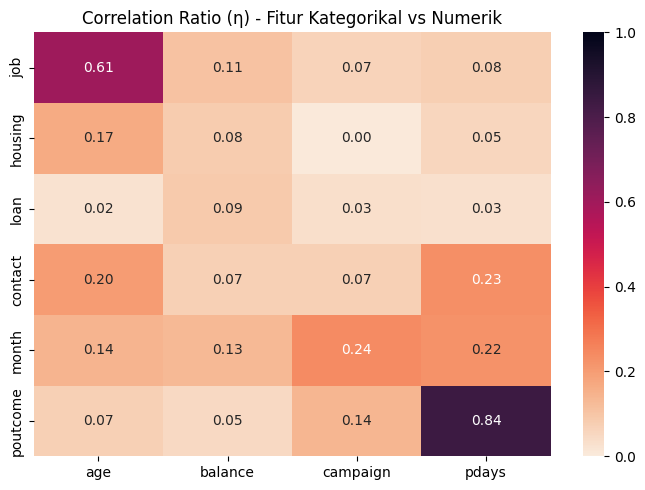

,age,balance,campaign,pdays
job,0.0000,0.0000,0.0004,0.0000
housing,0.0000,0.0000,0.7081,0.0000
loan,0.0317,0.0000,0.0027,0.0096
contact,0.0000,0.0000,0.0000,0.0000
month,0.0000,0.0000,0.0000,0.0000
poutcome,0.0000,0.0002,0.0000,0.0000


In [10]:
def correlation_ratio(categories, values):
    categories = pd.Series(categories).values
    values = pd.Series(values).values
    ss_total = np.sum((values - values.mean())**2)
    ss_between = 0
    for cat in pd.unique(categories):
        subgroup = values[categories == cat]
        ss_between += len(subgroup) * (subgroup.mean() - values.mean())**2
    return np.sqrt(ss_between / ss_total)

eta_matrix = pd.DataFrame(index=cat_features, columns=num_features, dtype=float)
pval_matrix = pd.DataFrame(index=cat_features, columns=num_features, dtype=float)

for c in cat_features:
    for n in num_features:
        eta_matrix.loc[c, n] = correlation_ratio(df[c], df[n])
        groups = [g[n].values for _, g in df.groupby(c)]
        f_stat, p_val = f_oneway(*groups)
        pval_matrix.loc[c, n] = p_val

plt.figure(figsize=(7, 5))
sns.heatmap(eta_matrix.astype(float), annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1)
plt.title("Correlation Ratio (η) - Fitur Kategorikal vs Numerik")
plt.tight_layout()
plt.show()

pval_matrix.round(4)

To close the gap in our multicollinearity screening, we checked the numerical-categorical pairing. We used the **correlation ratio (η)**, which measures how much of a numerical feature's variance is explained by a categorical grouping (0 = no relationship, 1 = numerical value is fully determined by the category), together with a one-way **ANOVA** to test whether the group means differ significantly:

* **`poutcome` vs `pdays` (η = 0.84, p < 0.001):** This is by far the strongest relationship in the matrix, and it is not a coincidence. Cross-checking the two columns shows that **5,809 of the 5,811 rows where `poutcome` is `unknown` also have `pdays = -1`** (the placeholder for "never contacted before"). In other words, these two features are encoding almost the same underlying fact from two different angles. Feeding both into a model as-is risks giving that single piece of information (whether the customer was previously contacted) outsized, duplicated weight.
* **`job` vs `age` (η = 0.61, p < 0.001):** The second-strongest pairing, which lines up with intuition: categories like `student` and `retired` are almost age-defined groups, so a large share of age's variance is already captured by job. This is a softer form of redundancy than `poutcome`/`pdays` since `job` also encodes information age does not (occupation type), but it is still worth being aware of for models that are sensitive to redundant predictors (e.g. unregularized linear/logistic regression).
* **Everything else is weak:** all remaining pairs sit at η ≤ 0.24. `housing` vs `campaign` is the only pair that is **not statistically significant** (p = 0.71), meaning whether a customer has a housing loan tells us nothing about how many times they were contacted this campaign.

## **1.4 Multivariate / Interaction Analysis**

### **1.4.1 `job` x `poutcome`**

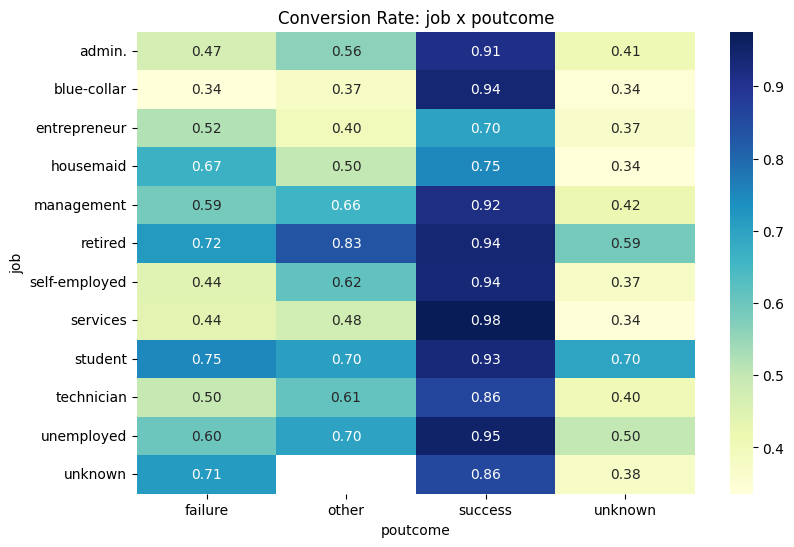

Chi-square = 924.09, p-value = 8.499e-164, dof = 46
Smallest cell count in the job x poutcome pivot: 5


poutcome,failure,other,success,unknown
job,,,,
admin.,134.0,48.0,92.0,662.0
blue-collar,125.0,67.0,67.0,1084.0
entrepreneur,25.0,5.0,10.0,196.0
housemaid,12.0,6.0,12.0,154.0
management,203.0,103.0,207.0,1276.0
retired,53.0,24.0,100.0,363.0
self-employed,27.0,13.0,31.0,209.0
services,73.0,23.0,41.0,521.0
student,28.0,27.0,44.0,148.0


In [11]:
pivot = (df.assign(deposit_flag=(df['deposit'] == 'yes').astype(int))
           .pivot_table(index='job', columns='poutcome', values='deposit_flag', aggfunc='mean'))

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Conversion Rate: job x poutcome")
plt.show()

job_poutcome = df['job'].astype(str) + "_" + df['poutcome'].astype(str)
ct_jp = pd.crosstab(job_poutcome, df['deposit'])
chi2_jp, p_jp, dof_jp, _ = chi2_contingency(ct_jp)

cell_counts_jp = df.pivot_table(index='job', columns='poutcome', values='deposit', aggfunc='count')

print(f"Chi-square = {chi2_jp:.2f}, p-value = {p_jp:.3e}, dof = {dof_jp}")
print(f"Smallest cell count in the job x poutcome pivot: {cell_counts_jp.min().min():.0f}")
cell_counts_jp

* **Statistically significant interaction:** chi-square = 924.1, p < 0.001 (8.5e-164). The job-poutcome combination is meaningfully associated with subscription outcome, not just noise.  
* **But reliability varies a lot cell-by-cell:** the pivot table mixes very well-sampled cells (e.g. `blue-collar` x `unknown`, n = 1,084) with extremely thin ones (e.g. `unknown` job x `success`/`other`, and several `entrepreneur`/`housemaid` cells with as few as **5 records**). Conversion rates read off those thin cells (visible as very high or very low values in the heatmap) are unstable and should not be treated as reliable segment insights on their own.
* **Takeaway:** the overall pattern (retirees/students who previously said `success` converting best, matching Section 1.2.2) is trustworthy, but any downstream business rule built on a single sparse job x poutcome cell should be treated with caution, or those rare job categories should be grouped before relying on them.


### **1.4.2 `age_group` x `housing`**

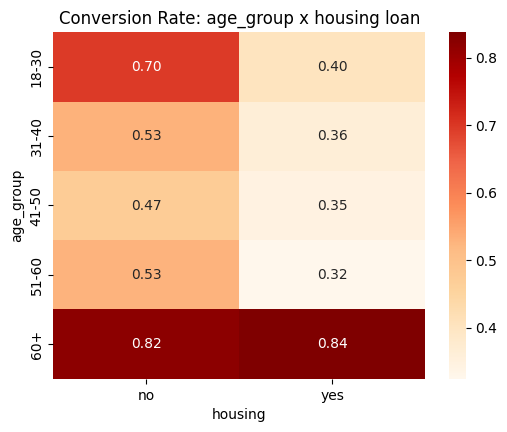

Chi-square = 586.44, p-value = 1.700e-120, dof = 9
Smallest cell count in the age_group x housing pivot: 37


housing,no,yes
age_group,,
18-30,768,622
31-40,1296,1659
41-50,861,873
51-60,808,478
60+,403,37


In [12]:
df_temp = df.copy()
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[17, 30, 40, 50, 60, 96],
                               labels=['18-30', '31-40', '41-50', '51-60', '60+'])
df_temp['deposit_flag'] = (df_temp['deposit'] == 'yes').astype(int)

pivot2 = df_temp.pivot_table(index='age_group', columns='housing', values='deposit_flag', aggfunc='mean')

plt.figure(figsize=(6, 4.5))
sns.heatmap(pivot2, annot=True, fmt=".2f", cmap="OrRd")
plt.title("Conversion Rate: age_group x housing loan")
plt.show()

age_housing = df_temp['age_group'].astype(str) + "_" + df_temp['housing'].astype(str)
ct_ah = pd.crosstab(age_housing, df_temp['deposit'])
chi2_ah, p_ah, dof_ah, _ = chi2_contingency(ct_ah)

cell_counts_ah = df_temp.pivot_table(index='age_group', columns='housing', values='deposit', aggfunc='count')

print(f"Chi-square = {chi2_ah:.2f}, p-value = {p_ah:.3e}, dof = {dof_ah}")
print(f"Smallest cell count in the age_group x housing pivot: {cell_counts_ah.min().min():.0f}")
cell_counts_ah

* **Statistically significant interaction:** chi-square = 586.4, p < 0.001 (1.7e-120), confirming the age/housing-loan combination carries real signal about deposit uptake, beyond what either feature explains alone.
* **Cell counts are comfortable across the board:** the smallest cell (60+ with a housing loan) still has **37 records**, and every other cell has several hundred. This is a much more reliable pivot table than `job x poutcome` above, so the pattern visible in the heatmap (younger clients with no housing loan, and especially older clients overall, converting at a higher rate) can be read with more confidence.

### **1.4.3 `month` x `contact`**

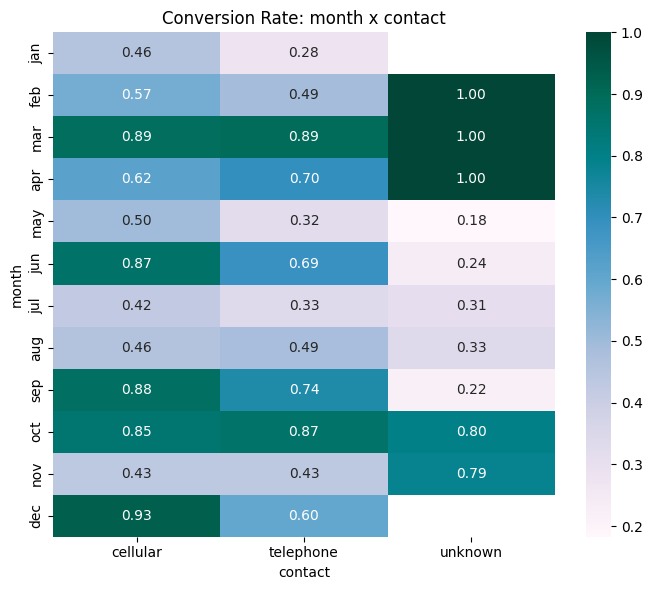

Chi-square = 1246.82, p-value = 7.417e-241, dof = 33
Smallest cell count in the month x contact pivot: 2


contact,cellular,telephone,unknown
month,,,
jan,202.0,25.0,NaN
feb,478.0,53.0,3.0
mar,178.0,19.0,2.0
apr,615.0,43.0,4.0
may,910.0,78.0,985.0
jun,275.0,16.0,566.0
jul,891.0,129.0,29.0
aug,1037.0,35.0,9.0
sep,184.0,19.0,9.0


In [13]:
pivot3 = (df.assign(deposit_flag=(df['deposit'] == 'yes').astype(int))
            .pivot_table(index='month', columns='contact', values='deposit_flag', aggfunc='mean'))

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
pivot3 = pivot3.reindex([m for m in month_order if m in pivot3.index])

plt.figure(figsize=(7, 6))
sns.heatmap(pivot3, annot=True, fmt=".2f", cmap="PuBuGn")
plt.title("Conversion Rate: month x contact")
plt.tight_layout()
plt.show()

month_contact = df['month'].astype(str) + "_" + df['contact'].astype(str)
ct_mc = pd.crosstab(month_contact, df['deposit'])
chi2_mc, p_mc, dof_mc, _ = chi2_contingency(ct_mc)

cell_counts_mc = df.pivot_table(index='month', columns='contact', values='deposit', aggfunc='count')
cell_counts_mc = cell_counts_mc.reindex([m for m in month_order if m in cell_counts_mc.index])

print(f"Chi-square = {chi2_mc:.2f}, p-value = {p_mc:.3e}, dof = {dof_mc}")
print(f"Smallest cell count in the month x contact pivot: {cell_counts_mc.min().min():.0f}")
cell_counts_mc

* **Statistically significant interaction:** chi-square = 1246.8, p < 0.001 (7.4e-241). The month-channel combination is strongly associated with subscription outcome.
* **`unknown` contact method behaves very differently depending on the month:** in the two highest-volume months, `may` (985 records) and `jun` (566 records), the `unknown` contact channel converts poorly (18.3% and 23.9%). In most other months the `unknown` channel is either near 100% or has too few records (as low as 2-15) to be trustworthy.
* **`cellular` and `telephone` are consistently strong, especially outside `may`:** months like `mar`, `jun`, `sep`, and `dec` show cellular/telephone conversion rates of 87-93%, well above the campaign's overall 47.8% baseline, while `may` (the largest month) drags the overall average down with cellular/telephone rates closer to 32-50%.
* **Takeaway:** `may` looks like a high-volume, lower-quality outreach period regardless of channel, whereas a handful of other months combined with a known contact channel are unusually high-converting. This is a concrete, reliable pattern (backed by large sample sizes for the `cellular`/`telephone` columns) that a model could exploit directly.

# **Section 1.5: Feature Engineering Opportunities**

Pulling together the patterns surfaced across 1.1-1.4, a few concrete feature engineering ideas stand out enough to be worth carrying into modeling:


* **`pdays_contacted` flag, decoupled from raw `pdays`.** Section 1.3.3 showed `poutcome` and `pdays` are near-duplicates (`poutcome = unknown` matches `pdays = -1` in 5,809 of 5,811 rows). Rather than feeding the raw, placeholder-laden `pdays` (`-1` mixed in with real day counts) directly into a model, split it into a simple binary **"was this customer contacted in a previous campaign?"** flag, and keep `poutcome` as the categorical detail of *how* that prior contact ended. The demo below shows this flag alone separates conversion rate from 40.8% (never contacted) to 68.1% (previously contacted) .
* **`age_group` bins instead of raw `age`.** Section 1.2.1 found the effect of age on `deposit` is not linear (flat in the middle, sharp uplift only past ~60), and Section 1.3.3 found `job` already explains 61% of age's variance through categories like `student`/`retired`. A binned `age_group` (as already used ad-hoc in 1.4.2) captures the non-linear relationship directly and is more robust to the age/job overlap than the raw continuous value.
* **Grouping rare `job` categories before using `job x poutcome` as a feature.** Section 1.4.1's reliability check found several job x poutcome cells with as few as 5 records (e.g. `entrepreneur`, `housemaid`, `unknown` job crossed with `other`/`success` poutcome). If an interaction feature between these two columns is built, collapsing the smallest job categories into an `"other"` bucket first would prevent the model from learning noisy, low-sample-size interaction effects.
* **A "high-conversion month" tier instead of raw `month`.** Section 1.4.3 showed conversion rate varies enormously by month (e.g. `mar`/`sep`/`dec` cellular/telephone conversion above 87%, versus `may`'s cellular/telephone conversion around 32-50%) independent of `contact` type. Encoding `month` as an ordered or grouped "season tier" (high / medium / low baseline conversion) rather than 12 raw categories would give lower-cardinality models a more direct version of a pattern that is currently split across many small categories.
* **Log-transform or bucket `balance`, with a separate "negative balance" flag.** Section 1.1.2 flagged `balance`'s skew, and Section 1.3.3 found `job` and `loan` both have a small but significant relationship with it (η ≈ 0.09-0.11, p < 0.001). A `log1p`-style transform (applied to the non-negative portion) plus a binary flag for negative balances would stabilize the distribution for scale-sensitive models without discarding the qualitative distinction between "in debt" and "low but positive balance."
